In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction import text
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

## Phrase frequency

In [ ]:
pefk = pd.read_csv("tmp.csv")

In [ ]:
mod_df = pefk[pefk['is_moderator'] == True]

In [ ]:
mod_df['text'] = mod_df['text'].str.lower()

/tmp/ipykernel_2463/3602308177.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_df['text'] = mod_df['text'].str.lower()


In [ ]:
# filter facilitator instances
mod_df = pefk[pefk['is_moderator'] == True].copy()

# cleanup
def clean_text(text_input):
    if pd.isna(text_input):
        return ""

    text_input = text_input.lower()

    # remove URLs
    text_input = re.sub(r'http\S+|www\S+', '', text_input)

    # remove punctuation & numbers
    text_input = re.sub(r'[^a-z\s]', '', text_input)

    # remove extra spaces
    text_input = re.sub(r'\s+', ' ', text_input).strip()

    return text_input

# apply cleaning
mod_df['clean_text'] = mod_df['text'].apply(clean_text)

# remove some stopwords
custom_stopwords = list(text.ENGLISH_STOP_WORDS) + [
    'http', 'www', 'org', 'wiki', 'wikipedia', 'en'
]

# function to extract phrases
def get_top_phrases(text_series, ngram_range=(2, 3), top_n=10):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        stop_words=custom_stopwords,
        min_df=2  # ignore rare phrases
    )

    X = vectorizer.fit_transform(text_series)

    # sum counts
    counts = X.sum(axis=0).A1
    phrases = vectorizer.get_feature_names_out()

    # combine and sort
    phrase_counts = list(zip(phrases, counts))
    phrase_counts = sorted(phrase_counts, key=lambda x: x[1], reverse=True)

    return phrase_counts[:top_n]

# run over all dataset
results = {}

for dataset, group in mod_df.groupby('dataset'):
    phrases = get_top_phrases(group['clean_text'])
    results[dataset] = phrases

for dataset, phrases in results.items():
    print(f"\nDataset: {dataset}")
    for phrase, count in phrases:
        print(f"{phrase}: {count}")


Dataset: ceri
thank comment: 163
welcome regulationroom: 122
regulation room: 110
thanks comment: 100
debt collectors: 86
welcome regulation: 82
welcome regulation room: 81
sounds like: 78
debt collection: 75
thank sharing: 64

Dataset: fora
im going: 922
little bit: 868
local voices: 775
voices network: 763
local voices network: 754
feel free: 521
make sure: 487
thank sharing: 398
city manager: 364
united way: 354

Dataset: iq2
intelligence squared: 853
arguing motion: 708
ladies gentlemen: 628
squared debate: 428
intelligence squared debate: 425
john donvan: 397
im going: 371
new york: 358
push number: 350
id like: 343

Dataset: umod
dont think: 10
does mean: 9
dont know: 7
doesnt mean: 6
im trying: 6
minimum wage: 6
change view: 5
climate change: 5
feel like: 5
men women: 5

Dataset: whow
im going: 345
arguing motion: 258
intelligence squared: 247
intelligence squared debate: 214
squared debate: 214
just want: 194
id like: 163
little bit: 161
news notes: 123
youre saying: 122

Data

In [ ]:
mod_df = pefk[pefk['is_moderator'] == True].copy().reset_index(drop=True)


def clean_text(text_input):
    if pd.isna(text_input):
        return ""

    text_input = text_input.lower()

    # fix glued words
    text_input = re.sub(r'regulationroom', 'regulation room', text_input)

    # remove urls
    text_input = re.sub(r'http\S+|www\S+', '', text_input)

    # keep letters only
    text_input = re.sub(r'[^a-z\s]', '', text_input)

    # collapse spaces
    text_input = re.sub(r'\s+', ' ', text_input).strip()

    return text_input

mod_df["clean_text"] = mod_df["text"].apply(clean_text)

# ---------------------------
# 3. Stopwords
# ---------------------------
custom_stopwords = list(text.ENGLISH_STOP_WORDS) + [
    'http', 'www', 'org', 'wiki', 'wikipedia', 'en'
]

# ---------------------------
# 4. TF-IDF
# ---------------------------
vectorizer = TfidfVectorizer(
    ngram_range=(2, 3),
    stop_words=custom_stopwords,
    min_df=2
)

X = vectorizer.fit_transform(mod_df["clean_text"])
feature_names = vectorizer.get_feature_names_out()

In [ ]:
results = {}

for dataset, group in mod_df.groupby("dataset"):

    idx = group.index.to_numpy()
    X_subset = X[idx]

    # mean TF-IDF per phrase
    scores = np.asarray(X_subset.mean(axis=0)).ravel()

    #  normalize within dataset (fix interpretability issue)
    if scores.max() > 0:
        scores = scores / scores.max()

    # top 10 phrases
    top_idx = scores.argsort()[::-1][:10]

    results[dataset] = [
        (feature_names[i], scores[i]) for i in top_idx
    ]

In [ ]:
rows = []

for dataset, phrases in results.items():
    for phrase, score in phrases:
        rows.append({
            "dataset": dataset,
            "phrase": phrase,
            "score": score
        })

plot_df = pd.DataFrame(rows)

/tmp/ipykernel_2463/2905873532.py:71: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(


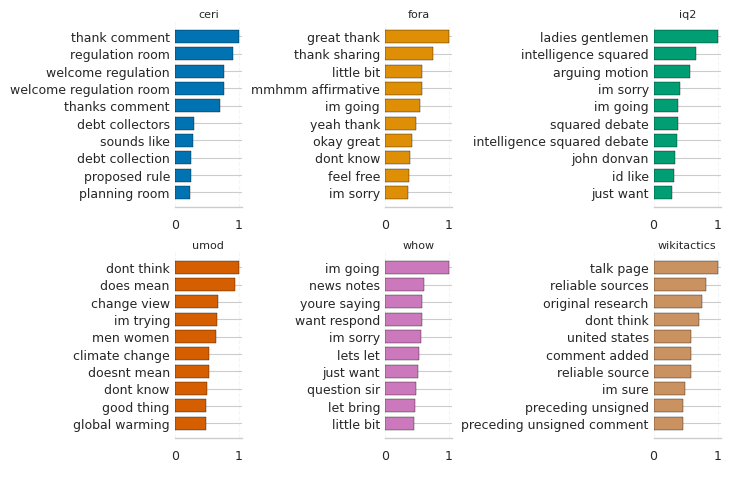

In [ ]:
dataset_order = ["ceri", "fora", "iq2", "umod", "whow", "wikitactics"]

colors = sns.color_palette("colorblind", 6)

sns.set_theme(style="whitegrid", context="paper")

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 8,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})


# 2x3 GRID
fig, axes = plt.subplots(
    2, 3,
    figsize=(7.2, 4.8),
    constrained_layout=True
)

axes = axes.flatten()

for i, dataset in enumerate(dataset_order):
    ax = axes[i]

    data = plot_df[plot_df["dataset"] == dataset] \
        .sort_values("score", ascending=True)

    # keep ALL phrases, but prevent visual chaos
    phrases = data["phrase"].tolist()
    scores = data["score"].tolist()

    # truncate softly
    def shorten(p):
        return p if len(p) <= 28 else p[:27] + "…"

    labels = [shorten(p) for p in phrases]

    ax.barh(
        labels,
        scores,
        color=colors[i],
        edgecolor="black",
        linewidth=0.25,
        height=0.75
    )

    ax.set_title(dataset, pad=3)

    ax.set_xlim(0, 1.05)


    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.2)
    ax.tick_params(axis='y', length=0)

    ax.set_xlabel("")


fig.supxlabel(
    " ",
    fontsize=8
)


plt.subplots_adjust(
    wspace=0.35,
    hspace=0.25
)

plt.savefig(
    "tfidf_pefk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()